In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Setting a theme
sns.set_theme(style='whitegrid')

#Make reproducible results
np.random.seed(42)

In [3]:
# Does design B 
n_samples_per_group = 1000
conversion_rate_a = 0.10 #Base conversion rate
conversion_rate_b = 0.13 #True conversion rate

In [4]:
#Generate synthetic data
data_a = np.random.binomial(n = 1, p =conversion_rate_a, size = n_samples_per_group) # 1 = converted, 0 = not_converted
data_b = np.random.binomial(n = 1, p =conversion_rate_b, size = n_samples_per_group)

In [5]:
df_a = pd.DataFrame({"group":"Design a(Control)", "Converted": data_a})
df_b = pd.DataFrame({"group":"Design b(Variant)", "Converted": data_b})
df = pd.concat([df_a, df_b], ignore_index = True)

In [18]:
print("SUMMARY STATISTICS")
summary = df.groupby("group")["Converted"].agg(
    total_users = "count",
    conversions = "sum",
    conversion_rate = "mean"
).reset_index()
print(summary.to_string(index = False))

SUMMARY STATISTICS
            group  total_users  conversions  conversion_rate
Design a(Control)         1000          100            0.100
Design b(Variant)         1000          131            0.131


In [22]:
rate_a = summary.loc[summary["group"] == "Design a(Control)", "conversion_rate"].values[0]
rate_b = summary.loc[summary["group"] == "Design b(Variant)", "conversion_rate"].values[0]
observed_diff = rate_b - rate_a
print(f"\n observed difference(lift):{observed_diff * 100:.2f}%") #100:.2f% reducing dp to 2dp


 observed difference(lift):3.10%


In [24]:
#Hypothesis testing
#h0 - no real improvement
#h1 - real improvement
n_a, n_b = summary["total_users"].values
conv_a, conv_b = summary["conversions"].values
p_pooled = (conv_a + conv_b) / (n_a + n_b)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_a + 1 / n_b)) # se - standard error

z_stat = observed_diff / se_pooled
p_value = 1 - stats.norm.cdf(z_stat) # 1 failed stat(1 tail statistics)

alpha = 0.05 
print("\n === 2.STATISTICAL HYPOTHESIS TEST RESULTS === ")
print(f" NULL HYPOTHESIS(HO): Design b <= Design a")
print(f" ALTERNATIVE HYPOTHESIS(H1): Design b > Design a")
print(f" Z STAT: {z_stat:.4f}")
print(f" P VALUE: {p_value:.5f}")
print(f" ALPHA: {alpha}")


 === 2.STATISTICAL HYPOTHESIS TEST RESULTS === 
 NULL HYPOTHESIS(HO): Design b <= Design a
 ALTERNATIVE HYPOTHESIS(H1): Design b > Design a
 Z STAT: 2.1687
 P VALUE: 0.01505
 ALPHA: 0.05


In [29]:
#Permutation simulation
print("RUNNING PERMUTATION SIMULATIONS, 10000 ITERATIONS")
n_simulations = 10000
simulated_diff = np.zeros(n_simulations)
all_conversions = df["Converted"].values
for i in range(n_simulations):
    shuffled_conversions = np.random.permutation(all_conversions)
    group_a_sim = shuffled_conversions[:n_samples_per_group]
    group_b_sim = shuffled_conversions[n_samples_per_group:]

    simulated_diff[i] = group_b_sim.mean()-group_a_sim.mean()
empirical_p_value = np.mean(simulated_diff >= observed_diff)
    
#Visualization

RUNNING PERMUTATION SIMULATIONS, 10000 ITERATIONS


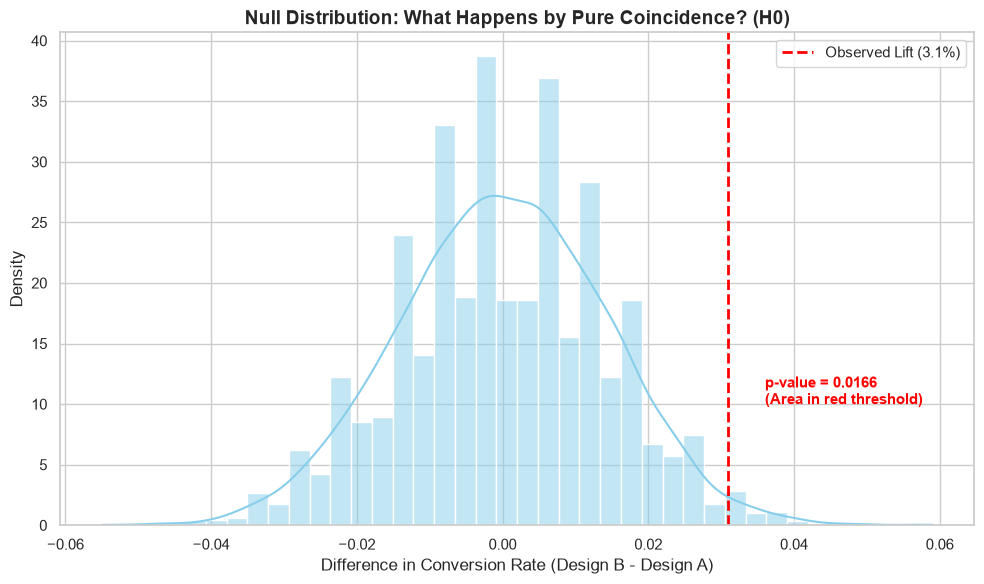

In [30]:
#Visualization
plt.figure(figsize=(10, 6))
sns.histplot(simulated_diff, kde=True, bins=40, color='skyblue', stat='density')
plt.axvline(x=observed_diff, color='red', linestyle='--', linewidth=2, 
            label=f'Observed Lift ({observed_diff*100:.1f}%)')

plt.title('Null Distribution: What Happens by Pure Coincidence? (H0)', fontsize=14, fontweight='bold')
plt.xlabel('Difference in Conversion Rate (Design B - Design A)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Highlight p-value area
plt.text(observed_diff + 0.005, 10, 
         f'p-value = {empirical_p_value:.4f}\n(Area in red threshold)', 
         color='red', fontweight='bold', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()
